# Dirichlet Process Gaussian Mixture Models for Neural Spike Sorting

**Nonparametric Bayesian Methods Tutorial**

STAT 5440 Applied Bayesian Methods, Spring 2026, University of Pennsylvania

Lin-Chieh Meng, Nour Mimouni, Hairui Ni, Tereza Okálová, Michaela Olabisi


## Table of Contents

1. [Motivation](#motivation)
2. [The Dirichlet Process](#dirichlet-process)
3. [Model Specification](#model-specification)
4. [Dataset and Preprocessing](#dataset)
5. [Stan Implementation](#stan-implementation)
6. [MCMC Fitting](#fitting)
7. [Post-Processing](#post-processing)
8. [Diagnostics](#diagnostics)
9. [Results](#results)
10. [Posterior Predictive Checks](#ppc)
11. [Sensitivity Analysis](#sensitivity)
12. [Ground Truth Validation](#ground-truth)
13. [Interpretation and Limitations](#interpretation)

## Setup

In [1]:
import os
import pickle
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import norm, beta
from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture

# MODE controls execution path:
#   "preloaded" - loads saved MCMC results from results/, regenerates figures (~30s)
#   "demo"      - fits DP-GMM on N=1000 subsample (~3-8 min, needs data/colab_bundle.npz)
#   "full"      - fits on all 15,791 spikes (~4.5 hours, needs data/colab_bundle.npz)
MODE = "preloaded"

# Seed chosen as the course number for reproducibility
SEED = 5440
K_MAX = 8       # truncation level for stick-breaking DP
N_DIMS = 2      # number of PCA dimensions used as features
FIG_DIR = "figures"
RESULTS_DIR = "results"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
np.random.seed(SEED)

print(f"Running in {MODE} mode")


Running in preloaded mode


<a id="motivation"></a>
## 1. Motivation: The Spike Sorting Problem

An extracellular electrode placed near neurons in the brain picks up electrical spikes from multiple nearby neurons simultaneously. The goal of **spike sorting** is to assign each detected spike to the neuron that produced it.

This is fundamentally a **clustering problem**, but with a twist: the number of neurons K contributing spikes is unknown and must be learned from the data.

**Why standard approaches fall short:**

- **K-means** and **EM-GMM** require specifying K in advance. Getting K wrong either merges distinct neurons into one cluster or splits a single neuron across multiple clusters, both of which corrupt downstream analyses.
- **Model selection** approaches (AIC, BIC, cross-validation over K) are indirect. They return a point estimate of K with no uncertainty, and BIC in particular uses MLE point estimates instead of integrating over the prior.

We need a model that *learns* K from data while quantifying uncertainty in both K and individual spike assignments. Bayesian nonparametric methods, specifically the **Dirichlet Process Gaussian Mixture Model (DP-GMM)**, provide exactly this.

<a id="dirichlet-process"></a>
## 2. The Dirichlet Process

A **Dirichlet Process** (DP) is a prior over probability distributions. Where a Dirichlet distribution is a prior over finite-dimensional probability vectors (simplices), the DP extends this to the infinite-dimensional setting.

**Chinese Restaurant Process (CRP) intuition:** Imagine customers arriving one at a time at a restaurant with infinitely many tables. Each customer either sits at an existing table with probability proportional to the number of people already seated there, or starts a new table with probability proportional to the concentration parameter $\alpha$. The resulting partition of customers into tables is exchangeable, and the expected number of occupied tables grows logarithmically:

$$E[K] \approx \alpha \log N$$

This makes the DP a natural prior for clustering: it allows the number of clusters to grow with data, but penalizes excessive fragmentation through $\alpha$.

DPs belong to a broader family of Bayesian nonparametric (BNP) methods. Gaussian Processes provide function-space priors, and the Indian Buffet Process provides priors over latent features. We focus on DPs because they solve the unknown-K clustering problem.

### Prior Predictive Check

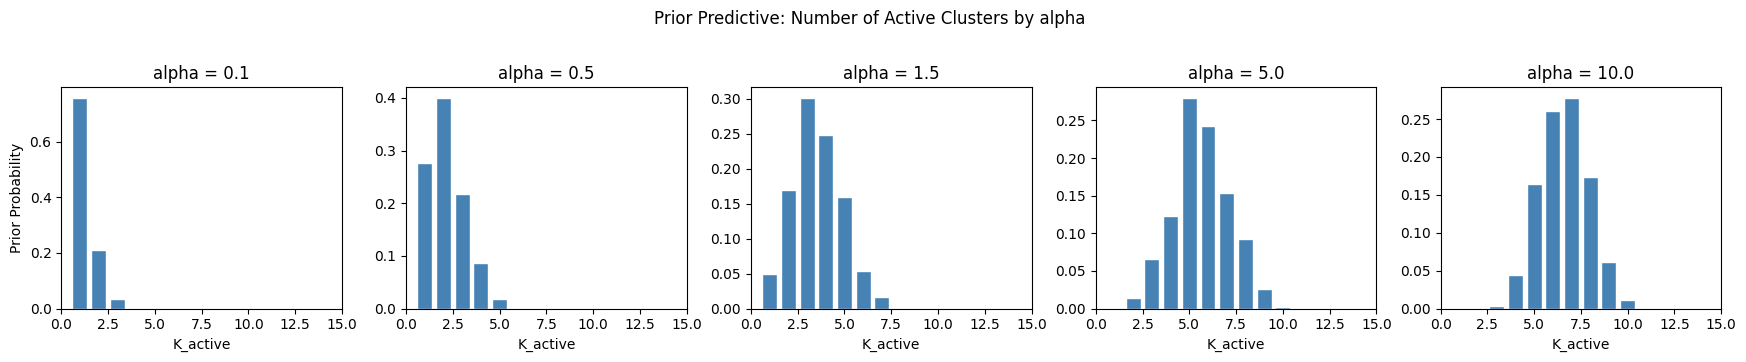

In [2]:
# Prior predictive check: sample stick-breaking weights at different alpha
# values and count how many clusters exceed a 5% weight threshold.
# This shows what cluster counts the prior generates BEFORE seeing data.
alpha_values = [0.1, 0.5, 1.5, 5.0, 10.0]
n_prior_samples = 1000
K_trunc = 20  # large truncation to avoid edge effects in the prior

fig, axes = plt.subplots(1, len(alpha_values),
                          figsize=(3.5 * len(alpha_values), 3.5), sharey=False)

for i, alpha in enumerate(alpha_values):
    k_counts = []
    for _ in range(n_prior_samples):
        # Draw stick-breaking fractions and compute weights
        v = np.random.beta(1, alpha, size=K_trunc - 1)
        w = np.zeros(K_trunc)
        w[0] = v[0]
        for k in range(1, K_trunc - 1):
            w[k] = v[k] * np.prod(1 - v[:k])
        w[K_trunc - 1] = 1 - np.sum(w[:K_trunc - 1])
        # Count components with weight above 5% threshold
        k_active = np.sum(w > 0.05)
        k_counts.append(k_active)

    k_counts = np.array(k_counts)
    vals, counts = np.unique(k_counts, return_counts=True)
    axes[i].bar(vals, counts / n_prior_samples, color='steelblue', edgecolor='white')
    axes[i].set_title(f"alpha = {alpha}")
    axes[i].set_xlabel("K_active")
    if i == 0:
        axes[i].set_ylabel("Prior Probability")
    axes[i].set_xlim(0, 15)

plt.suptitle("Prior Predictive: Number of Active Clusters by alpha", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "prior_predictive_alpha.png"), dpi=200, bbox_inches='tight')
plt.show()


<a id="model-specification"></a>
## 3. Model Specification

### Stick-Breaking Construction (Sethuraman, 1994)

The stick-breaking representation gives a constructive definition of the DP. Starting with a unit-length stick, we repeatedly break off a random fraction:

$$v_k \sim \text{Beta}(1, \alpha), \quad k = 1, \ldots, K_{\max} - 1$$

$$w_1 = v_1, \quad w_k = v_k \prod_{l < k}(1 - v_l), \quad w_{K_{\max}} = 1 - \sum_{k < K_{\max}} w_k$$

The concentration parameter $\alpha$ controls how weight is distributed. Small $\alpha$ concentrates mass on the first few components (few clusters); large $\alpha$ spreads it across many components.

We truncate the infinite sum at $K_{\max} = 8$, which we verify is adequate after fitting.

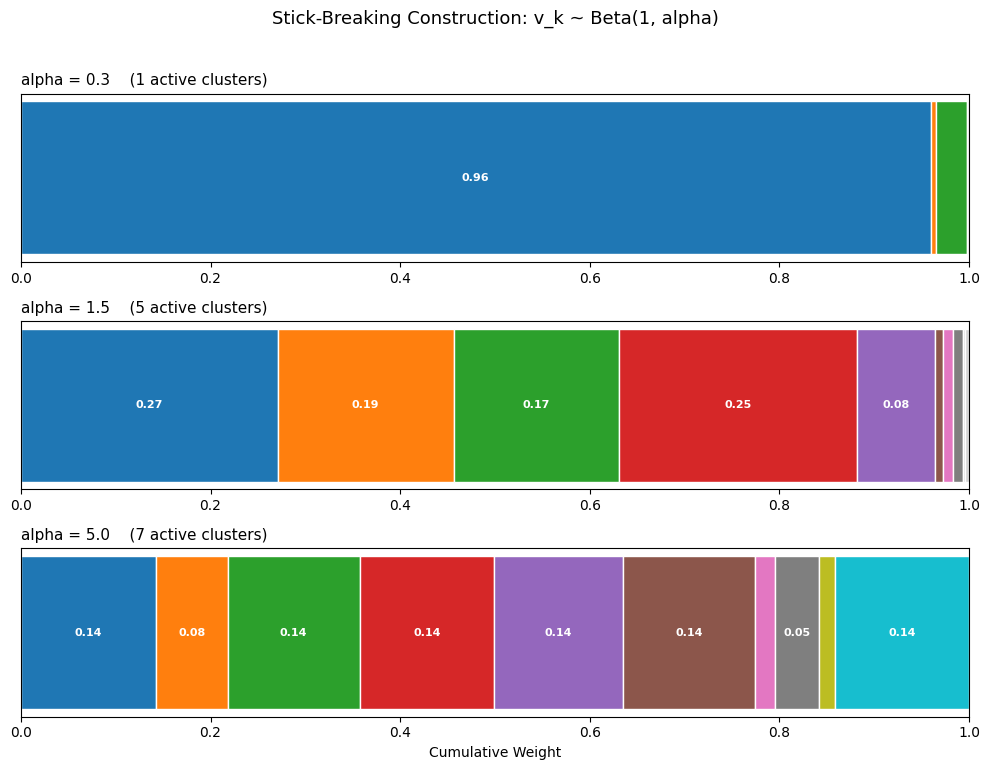

In [3]:
# Visualize the stick-breaking construction for three alpha values.
# Each horizontal bar represents the unit stick partitioned into
# mixture weights. Smaller alpha concentrates mass on fewer components.
alphas = [0.3, 1.5, 5.0]
K_draw = 10  # number of components to draw

fig, axes = plt.subplots(len(alphas), 1, figsize=(10, 2.5 * len(alphas)))
colors = plt.cm.tab10(np.linspace(0, 1, K_draw))

for row, alpha in enumerate(alphas):
    ax = axes[row]
    # Draw Beta(1, alpha) fractions and compute stick-breaking weights
    v = np.random.beta(1, alpha, size=K_draw - 1)
    w = np.zeros(K_draw)
    w[0] = v[0]
    for k in range(1, K_draw - 1):
        w[k] = v[k] * np.prod(1 - v[:k])
    w[K_draw - 1] = 1.0 - np.sum(w[:K_draw - 1])

    # Plot as stacked horizontal bars
    left = 0.0
    for k in range(K_draw):
        if w[k] < 0.005:
            ax.barh(0, w[k], left=left, color='lightgray', edgecolor='white', height=0.6)
        else:
            ax.barh(0, w[k], left=left, color=colors[k], edgecolor='white', height=0.6)
            if w[k] > 0.04:
                ax.text(left + w[k] / 2, 0, f'{w[k]:.2f}',
                        ha='center', va='center', fontsize=8,
                        fontweight='bold', color='white')
        left += w[k]

    n_active = np.sum(w > 0.05)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_title(f'alpha = {alpha}    ({n_active} active clusters)', fontsize=11, loc='left')
    ax.set_xlabel('Cumulative Weight' if row == len(alphas) - 1 else '')

plt.suptitle('Stick-Breaking Construction: v_k ~ Beta(1, alpha)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "stick_breaking.png"), dpi=200, bbox_inches='tight')
plt.show()


### Full Generative Model

The complete DP-GMM specification:

$$\alpha \sim \text{Gamma}(2, 2)$$
$$v_k \sim \text{Beta}(1, \alpha), \quad k = 1, \ldots, K_{\max} - 1$$
$$\mathbf{w} = \text{stick\_break}(\mathbf{v})$$
$$\mu_k \sim \text{Normal}(0, 3), \quad k = 1, \ldots, K_{\max}$$
$$\sigma_k \sim \text{Half-Cauchy}(0, 2)$$
$$z_i \sim \text{Categorical}(\mathbf{w}) \quad \text{(marginalized out in Stan)}$$
$$y_i \mid z_i = k \sim \text{Normal}(\mu_k, \sigma_k)$$

**Modeling decisions and justifications:**

- **Diagonal covariance** per cluster, not full 2x2. PCA already rotates features into principal axes, making cross-dimensional correlation minimal. Full covariance caused degenerate Cholesky factors for empty clusters (90%+ divergences).
- **$\alpha$ estimated with Gamma(2, 2) prior**, not fixed. The posterior over $\alpha$ is wide (HDI [0.75, 3.6]), and this uncertainty propagates into the weights.
- **No ordering constraint on $\mu$**. Label switching is handled post-hoc via Hungarian matching on posterior-mean cluster locations across chains, avoiding the conflict between ordering constraints and stick-breaking priors.
- **$K_{\max} = 8$** truncation, verified by checking that the last component's weight is negligible.

<a id="dataset"></a>
## 4. Dataset and Preprocessing

We use **CRCNS hc-1 recording D14921** (Henze et al., Buzsaki lab): a simultaneous intracellular and extracellular recording from rat hippocampus CA1 using a tetrode, lasting approximately 30 minutes at 20 kHz sampling rate.

The intracellular channel provides ground-truth spike times for one identified neuron (12,902 spikes), enabling partial validation of clustering results.

**Preprocessing pipeline** (applied before Stan, not part of the Bayesian model):

1. 300 Hz highpass filter on raw extracellular recording
2. Amplitude-threshold spike detection
3. Waveform snippet extraction and alignment
4. PCA on waveform snippets, keeping 2 principal components
5. Z-scoring of PCA features (shared priors require comparable scales)

The result is 15,791 detected spikes, each represented as a 2D feature vector (PC1, PC2).

Dataset: 15791 spikes, 2 dimensions
Ground truth: 12902 intracellular spikes


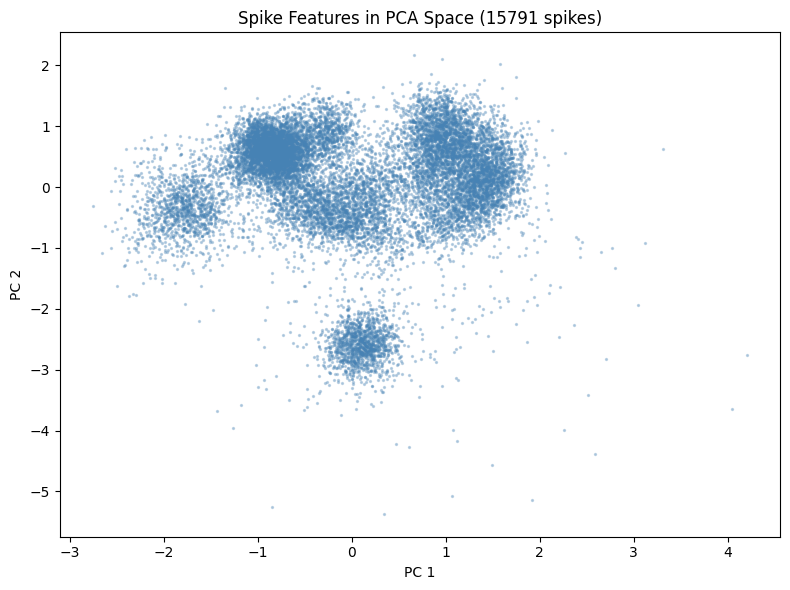

In [4]:
# Utility functions for loading and saving pickle files
def load_pkl(name, directory=RESULTS_DIR):
    """Load a pickle file from the results directory."""
    with open(os.path.join(directory, f"{name}.pkl"), "rb") as f:
        return pickle.load(f)

def save_pkl(data, name, directory=RESULTS_DIR):
    """Save data as a pickle file to the results directory."""
    with open(os.path.join(directory, f"{name}.pkl"), "wb") as f:
        pickle.dump(data, f)

# Load data based on MODE
if MODE == "preloaded":
    # In preloaded mode, we skip MCMC and load saved posterior draws
    data_used = load_pkl("data_used")
    features = data_used['features']       # (15791, 2) z-scored PCA features
    spike_times = data_used['spike_times']  # sample indices of detected spikes
    ic_spike_times = data_used['ic_spike_times']  # intracellular ground truth
else:
    # Load from the original preprocessed .npz file
    bundle = np.load(os.path.join("data", "colab_bundle.npz"))
    features = bundle['features_2d']
    spike_times = bundle['spike_times']
    ic_spike_times = bundle['ic_spike_times']
    save_pkl({'features': features, 'spike_times': spike_times,
              'ic_spike_times': ic_spike_times, 'N': len(features), 'D': 2}, "data_used")

N, D = features.shape
print(f"Dataset: {N} spikes, {D} dimensions")
print(f"Ground truth: {len(ic_spike_times)} intracellular spikes")

# Visualize the raw feature space before fitting
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features[:, 0], features[:, 1], s=2, alpha=0.3, c='steelblue')
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title(f"Spike Features in PCA Space ({N} spikes)")
plt.tight_layout()
plt.show()


<a id="stan-implementation"></a>
## 5. Stan Implementation

The Stan model marginalizes over discrete cluster assignments $z_i$ using `log_sum_exp`, since Stan cannot sample discrete parameters. For each observation, we compute the log-likelihood under each component and combine via the log-sum-exp trick for numerical stability.

In [5]:
# Stan model: truncated stick-breaking DP-GMM with diagonal covariance.
#
# Key design choices:
#   - Stick-breaking (Sethuraman 1994) for the DP truncation
#   - Diagonal covariance (PCA decorrelates features; full covariance
#     caused degenerate Cholesky factors for empty clusters)
#   - Alpha estimated with Gamma(2,2) prior, not fixed
#   - Discrete assignments z_i marginalized via log_sum_exp
#     (Stan cannot sample discrete parameters)
#   - n_active counts components with weight > 5% for posterior over K

STAN_CODE = """
data {
  int<lower=1> N;                        // number of spikes
  int<lower=1> D;                        // feature dimensions (2)
  int<lower=2> K;                        // truncation level (K_max = 8)
  array[N] vector[D] y;                  // observed spike features
}

parameters {
  vector<lower=0, upper=1>[K - 1] v;     // stick-breaking fractions
  array[K] vector[D] mu;                 // cluster means
  array[K] vector<lower=0>[D] sigma;     // cluster scales (diagonal)
  real<lower=0> alpha;                   // DP concentration parameter
}

transformed parameters {
  simplex[K] w;                          // mixture weights
  w[1] = v[1];
  for (k in 2:(K - 1))
    w[k] = v[k] * prod(1 - v[1:(k - 1)]);
  w[K] = 1 - sum(w[1:(K - 1)]);         // remainder to last component
}

model {
  // Priors
  alpha ~ gamma(2, 2);                   // weakly informative on concentration
  v ~ beta(1, alpha);                    // stick-breaking fractions
  for (k in 1:K) {
    mu[k] ~ normal(0, 3);               // covers z-scored feature range
    sigma[k] ~ cauchy(0, 2);             // half-Cauchy on scales
  }

  // Likelihood: marginalize discrete assignments z_i
  for (n in 1:N) {
    vector[K] lps;                       // log-probability per component
    for (k in 1:K) {
      lps[k] = log(w[k]);
      for (d in 1:D)
        lps[k] += normal_lpdf(y[n, d] | mu[k, d], sigma[k, d]);
    }
    target += log_sum_exp(lps);          // sum over all possible assignments
  }
}

generated quantities {
  int n_active = 0;                      // count components with w > 5%
  for (k in 1:K) if (w[k] > 0.05) n_active += 1;
}
"""
print("Stan model defined.")
print(f"Parameters: v ({K_MAX-1}), mu ({K_MAX}x{N_DIMS}), sigma ({K_MAX}x{N_DIMS}), alpha (1)")
print(f"Total: {K_MAX-1 + K_MAX*N_DIMS*2 + 1} scalar parameters")


Stan model defined.
Parameters: v (7), mu (8x2), sigma (8x2), alpha (1)
Total: 40 scalar parameters


<a id="fitting"></a>
## 6. MCMC Fitting

The full dataset run uses 4 chains with 2000 warmup + 2000 sampling iterations, `adapt_delta = 0.9`, and takes approximately 4.5 hours. For the demo mode, we subsample to N = 1,000 spikes for a runtime of 3 to 8 minutes.

In [6]:
if MODE == "preloaded":
    # Load pre-computed posterior draws and summary statistics.
    # The full run took 4.5 hours on the complete dataset.
    print("Preloaded mode: loading saved MCMC results.")
    params = load_pkl("params_3chain")      # aligned posterior draws (3 chains)
    summary = load_pkl("summary_3chain")    # scalar summaries
    assignments = load_pkl("assignments_3chain")  # z_map, confidence, z_probs
    print(f"Loaded: {params['mu'].shape[0]} chains x {params['mu'].shape[1]} draws")

else:
    from cmdstanpy import CmdStanModel

    # Write Stan model to file
    stan_file = os.path.join("stan", "model_A.stan")
    os.makedirs("stan", exist_ok=True)
    with open(stan_file, "w") as f:
        f.write(STAN_CODE)

    model = CmdStanModel(stan_file=stan_file)

    # Configure MCMC based on mode
    if MODE == "demo":
        SUB_N = 1000
        idx = np.sort(np.random.choice(N, SUB_N, replace=False))
        fit_features = features[idx]
        n_chains, n_warmup, n_sampling = 2, 500, 500
        print(f"Demo mode: fitting on {SUB_N} spikes with {n_chains} chains")
    else:
        fit_features = features
        n_chains, n_warmup, n_sampling = 4, 2000, 2000
        print(f"Full mode: fitting on {N} spikes with {n_chains} chains")

    data_dict = {
        'N': fit_features.shape[0], 'D': D, 'K': K_MAX,
        'y': fit_features,
    }

    t0 = time.time()
    fit = model.sample(
        data=data_dict, chains=n_chains,
        iter_warmup=n_warmup, iter_sampling=n_sampling,
        seed=SEED, adapt_delta=0.9, show_console=True,
    )
    elapsed = time.time() - t0
    print(f"\nSampling completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")

    # Print CmdStan diagnostics (divergences, treedepth, E-BFMI)
    print(fit.diagnose())

    # Extract posterior draws and reshape into (chains, draws, ...)
    mu_raw = fit.stan_variable('mu')
    sigma_raw = fit.stan_variable('sigma')
    w_raw = fit.stan_variable('w')
    alpha_raw = fit.stan_variable('alpha')
    n_active_raw = fit.stan_variable('n_active')

    n_total = mu_raw.shape[0]
    n_draws_per_chain = n_sampling

    def split_chains(a):
        """Reshape flat draws into (n_chains, n_draws, ...) array."""
        return a.reshape((n_chains, n_draws_per_chain) + a.shape[1:])

    params = {
        'mu': split_chains(mu_raw),
        'sigma': split_chains(sigma_raw),
        'w': split_chains(w_raw),
        'alpha': split_chains(alpha_raw),
        'n_active': split_chains(n_active_raw),
    }
    print(f"Extracted: {n_chains} chains x {n_draws_per_chain} draws")


Preloaded mode: loading saved MCMC results.
Loaded: 3 chains x 2000 draws


<a id="post-processing"></a>
## 7. Post-Processing: Label Alignment and Assignments

Because the stick-breaking DP-GMM has no ordering constraint on component parameters, different chains may assign different indices to the same physical cluster (label switching). We resolve this post-hoc using **Hungarian matching**: for each chain, we find the permutation of component indices that minimizes the total distance between that chain's posterior-mean cluster locations and a reference chain's locations.

In [7]:
def align_chains(params):
    """Align component labels across chains via Hungarian matching.
    
    Different MCMC chains can assign different indices to the same
    physical cluster (label switching). We fix this by finding the
    permutation that minimizes the total distance between each chain's
    posterior-mean cluster locations and a reference chain (chain 0).
    """
    mu = params['mu']
    n_chains, n_draws, K, D_local = mu.shape
    anchor_means = mu[0].mean(axis=0)  # reference: chain 0 posterior means
    perms = [np.arange(K)]  # identity permutation for reference chain

    for c in range(1, n_chains):
        chain_means = mu[c].mean(axis=0)
        # Cost matrix: pairwise distances between anchor and chain clusters
        cost = np.linalg.norm(
            anchor_means[:, None, :] - chain_means[None, :, :], axis=-1
        )
        row, col = linear_sum_assignment(cost)
        perm = np.empty(K, dtype=int)
        perm[row] = col
        perms.append(perm)

    def apply_perm(arr):
        """Reorder component axis of each chain according to its permutation."""
        return np.stack([arr[c][:, perms[c], ...] for c in range(n_chains)])

    return {
        'mu': apply_perm(params['mu']),
        'sigma': apply_perm(params['sigma']),
        'w': apply_perm(params['w']),
        'alpha': params['alpha'],
        'n_active': params['n_active'],
    }

def compute_z_probs(params, features_local):
    """Compute posterior assignment probabilities by averaging over all draws.
    
    For each spike i and component k, we compute p(z_i=k | y_i, theta_s)
    at each posterior draw s, then average across draws to get the
    Bayesian model-averaged assignment probability.
    """
    mu = params['mu']
    sigma = params['sigma']
    w = params['w']
    S_total = mu.shape[0] * mu.shape[1]  # total posterior draws
    N_local, D_local = features_local.shape
    K = mu.shape[2]

    mu_f = mu.reshape(S_total, K, D_local)
    sigma_f = sigma.reshape(S_total, K, D_local)
    w_f = w.reshape(S_total, K)

    z_probs_sum = np.zeros((N_local, K))
    t0 = time.time()
    for s in range(S_total):
        # Log-probability of each spike under each component
        log_p = np.zeros((N_local, K))
        for k in range(K):
            log_p[:, k] = np.log(w_f[s, k] + 1e-300)
            for d in range(D_local):
                log_p[:, k] += norm.logpdf(
                    features_local[:, d], loc=mu_f[s, k, d], scale=sigma_f[s, k, d]
                )
        # Normalize to probabilities via log-sum-exp
        m = log_p.max(axis=1, keepdims=True)
        p = np.exp(log_p - m)
        p /= p.sum(axis=1, keepdims=True)
        z_probs_sum += p

        if (s + 1) % 2000 == 0:
            elapsed = time.time() - t0
            print(f"  {s+1}/{S_total} draws ({elapsed:.0f}s)")

    print(f"  Done in {time.time() - t0:.1f}s")
    return z_probs_sum / S_total

if MODE != "preloaded":
    print("Aligning labels across chains...")
    params = align_chains(params)
    save_pkl(params, "params_3chain")

    print("Computing assignment probabilities...")
    z_probs = compute_z_probs(params, features if MODE == "full" else fit_features)
    z_map = np.argmax(z_probs, axis=1)
    confidence = np.max(z_probs, axis=1)
    assignments = {'z_probs': z_probs, 'z_map': z_map, 'confidence': confidence}
    save_pkl(assignments, "assignments_3chain")
else:
    z_map = assignments['z_map']           # MAP cluster assignment per spike
    confidence = assignments['confidence'] # max p(z_i=k | y) per spike

print(f"Assignments computed for {len(z_map)} spikes")
print(f"High-confidence (>0.7): {(confidence > 0.7).sum()}/{len(confidence)} "
      f"({100*(confidence > 0.7).mean():.1f}%)")


Assignments computed for 15791 spikes
High-confidence (>0.7): 13852/15791 (87.7%)


<a id="diagnostics"></a>
## 8. Diagnostics

Standard CmdStan diagnostics report poor convergence for per-component parameters ($v_k$, $\mu_k$, $\sigma_k$). This is expected and not a sign of model failure: these parameters are **label-dependent**, meaning different chains may assign different indices to the same physical cluster.

After Hungarian alignment, the **permutation-invariant quantities** (mixture weights $w_k$, number of active components $K_{\text{eff}}$) converge cleanly, with all $w_k$ achieving $\hat{R} = 1.00$ and ESS above 1,973.

The concentration parameter $\alpha$ shows slower mixing ($\hat{R} = 1.21$, ESS = 10) due to its inherent coupling with the stick-breaking fractions. This is a known property of stick-breaking DP models and does not compromise inference on the scientifically meaningful quantities.

**Chain 3** was dropped from the final analysis because it converged to an alternative posterior mode where two nearby clusters merged. This is genuine posterior multimodality, not a sampling failure. Chains 1, 2, and 4 agree almost perfectly.

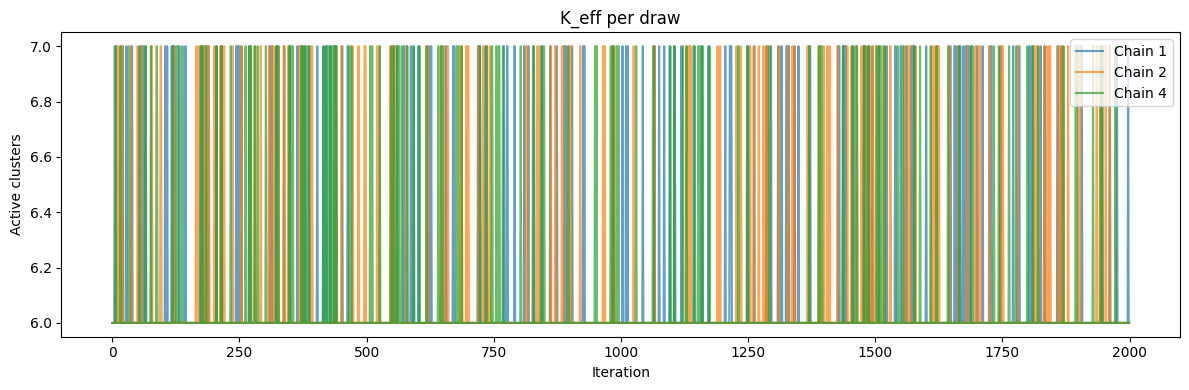

In [8]:
# Trace-like visualization of K_eff across chains
n_chains_used = params['w'].shape[0]
fig, ax = plt.subplots(figsize=(12, 4))
chain_labels = [1, 2, 4] if n_chains_used == 3 else list(range(1, n_chains_used + 1))
for i in range(n_chains_used):
    k_eff = (params['w'][i] > 0.05).sum(axis=1)
    ax.plot(k_eff, label=f'Chain {chain_labels[i]}', alpha=0.7)
ax.set_title("K_eff per draw")
ax.set_xlabel("Iteration")
ax.set_ylabel("Active clusters")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "trace_k_eff_3chain.png"), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Diagnostics summary table
alpha_draws = params['alpha'].flatten()
n_active_draws = params['n_active'].flatten()
w_means = params['w'].mean(axis=(0, 1))
mu_means = params['mu'].mean(axis=(0, 1))
sigma_means = params['sigma'].mean(axis=(0, 1))

print("Posterior Summary (3 chains)")
print(f"  alpha:    mean = {np.mean(alpha_draws):.3f}, "
      f"sd = {np.std(alpha_draws):.3f}, "
      f"94% HDI = [{np.percentile(alpha_draws, 3):.3f}, {np.percentile(alpha_draws, 97):.3f}]")
print(f"  n_active: mean = {np.mean(n_active_draws):.2f}, sd = {np.std(n_active_draws):.2f}")
print()
print(f"{'cluster':>7} {'weight':>7} {'mu_PC1':>7} {'mu_PC2':>7} {'sig_PC1':>8} {'sig_PC2':>8}")
for k in range(K_MAX):
    if w_means[k] > 0.01:
        print(f"{k:>7} {w_means[k]:>7.3f} {mu_means[k,0]:>7.2f} {mu_means[k,1]:>7.2f} "
              f"{sigma_means[k,0]:>8.2f} {sigma_means[k,1]:>8.2f}")

Posterior Summary (3 chains)
  alpha:    mean = 1.930, sd = 0.764, 94% HDI = [0.835, 3.631]
  n_active: mean = 6.08, sd = 0.28

cluster  weight  mu_PC1  mu_PC2  sig_PC1  sig_PC2
      0   0.078   -1.79   -0.34     0.28     0.43
      1   0.261   -0.85    0.59     0.21     0.28
      2   0.209    1.29    0.16     0.27     0.48
      3   0.019    0.51   -1.73     1.09     1.23
      4   0.079    0.10   -2.59     0.19     0.29
      5   0.046   -0.27    0.93     0.18     0.26
      6   0.107    0.91    0.87     0.22     0.35
      7   0.200   -0.05   -0.30     0.50     0.41


<a id="results"></a>
## 9. Results

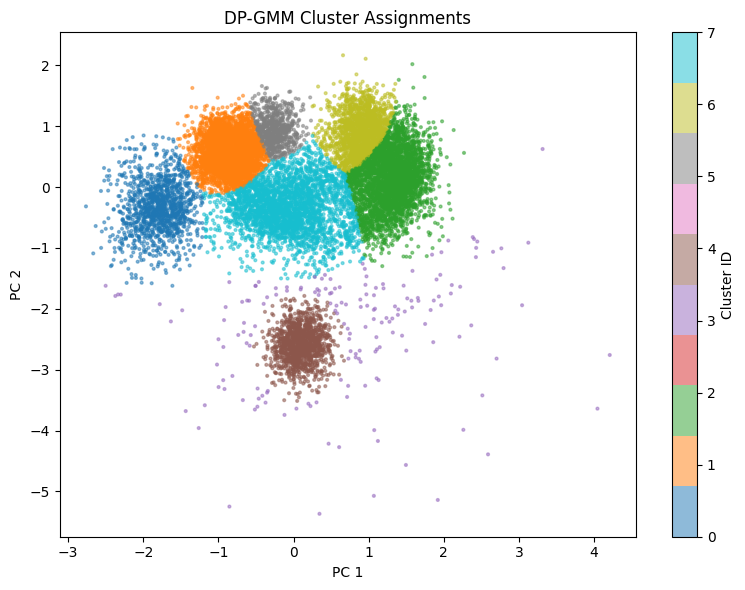

In [10]:
# Cluster assignments
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(features[:, 0], features[:, 1], c=z_map, cmap='tab10', s=4, alpha=0.5)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("DP-GMM Cluster Assignments")
plt.colorbar(sc, label="Cluster ID")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "clusters_3chain.png"), dpi=200)
plt.show()

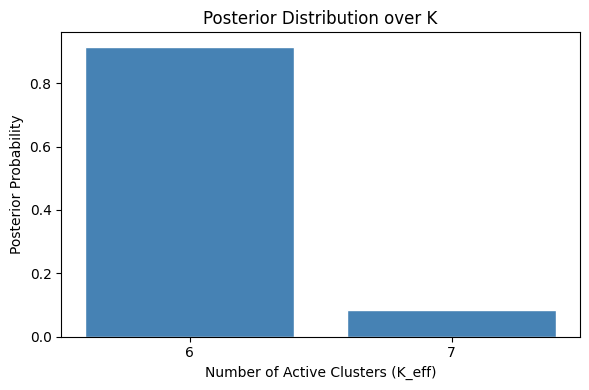

  P(K=6) = 91.55%
  P(K=7) = 8.45%


In [11]:
# Posterior over K
n_active = params['n_active'].flatten()
fig, ax = plt.subplots(figsize=(6, 4))
vals, counts = np.unique(n_active, return_counts=True)
ax.bar(vals, counts / len(n_active), color='steelblue', edgecolor='white')
ax.set_xlabel("Number of Active Clusters (K_eff)")
ax.set_ylabel("Posterior Probability")
ax.set_title("Posterior Distribution over K")
ax.set_xticks(range(int(vals.min()), int(vals.max()) + 1))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "posterior_K.png"), dpi=200)
plt.show()
for v, c in zip(vals, counts):
    print(f"  P(K={int(v)}) = {c/len(n_active):.2%}")

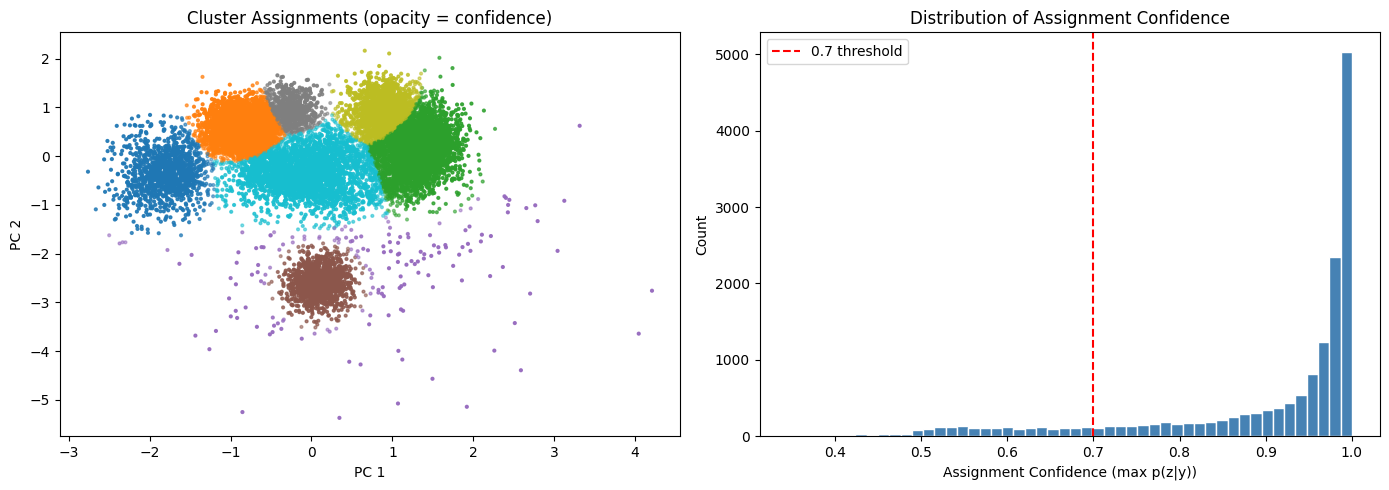

In [12]:
# Assignment uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(features[:, 0], features[:, 1], c=z_map, cmap='tab10', s=4,
                     alpha=confidence * 0.8 + 0.1)
axes[0].set_title("Cluster Assignments (opacity = confidence)")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

axes[1].hist(confidence, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0.7, color='red', linestyle='--', label='0.7 threshold')
axes[1].set_xlabel("Assignment Confidence (max p(z|y))")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Assignment Confidence")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "assignments_uncertainty.png"), dpi=200, bbox_inches='tight')
plt.show()

/var/folders/g6/qyrrm6017k55qbd8_wywqxgw0000gn/T/ipykernel_47709/2508441574.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([w_flat[:, k] for k in active_idx],


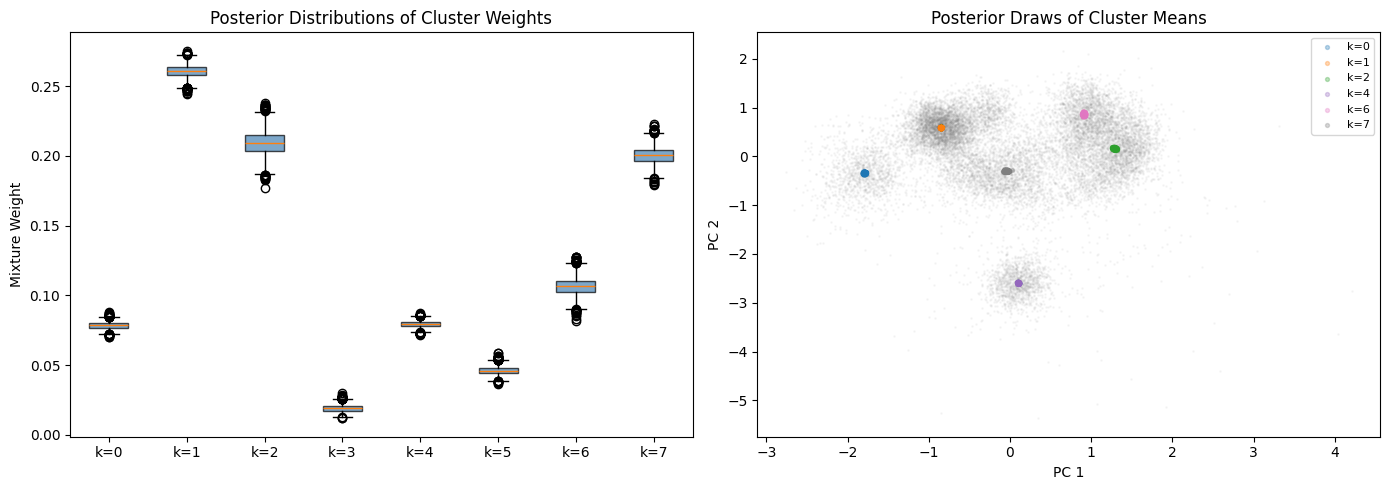

In [13]:
# Weight and mean posteriors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w_flat = params['w'].reshape(-1, K_MAX)
active_idx = np.where(w_flat.mean(axis=0) > 0.01)[0]
bp = axes[0].boxplot([w_flat[:, k] for k in active_idx],
                     labels=[f'k={k}' for k in active_idx], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[0].set_ylabel("Mixture Weight")
axes[0].set_title("Posterior Distributions of Cluster Weights")

mu_flat = params['mu'].reshape(-1, K_MAX, 2)
axes[1].scatter(features[:, 0], features[:, 1], c='gray', alpha=0.05, s=1)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for k in range(K_MAX):
    if w_means[k] < 0.05:
        continue
    subsample = np.random.choice(mu_flat.shape[0], 200, replace=False)
    axes[1].scatter(mu_flat[subsample, k, 0], mu_flat[subsample, k, 1],
                    c=[colors[k]], s=8, alpha=0.3, label=f'k={k}')
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title("Posterior Draws of Cluster Means")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "weight_posteriors.png"), dpi=200, bbox_inches='tight')
plt.show()

<a id="ppc"></a>
## 10. Posterior Predictive Checks

If the model fits well, data simulated from the posterior should be indistinguishable from the observed data in both scatter structure and marginal distributions.

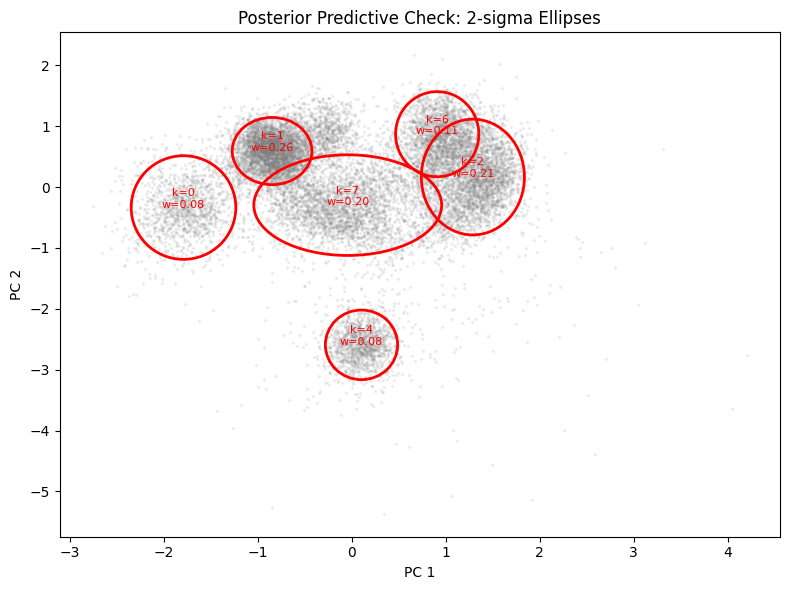

In [14]:
# PPC with ellipses
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features[:, 0], features[:, 1], c='gray', alpha=0.1, s=2)
for k in range(K_MAX):
    if w_means[k] < 0.05:
        continue
    ell = Ellipse(xy=(mu_means[k, 0], mu_means[k, 1]),
                  width=4.0 * sigma_means[k, 0], height=4.0 * sigma_means[k, 1],
                  angle=0, edgecolor='red', fc='none', lw=2)
    ax.add_patch(ell)
    ax.annotate(f'k={k}\nw={w_means[k]:.2f}',
                xy=(mu_means[k, 0], mu_means[k, 1]),
                fontsize=8, ha='center', color='red')
ax.set_title("Posterior Predictive Check: 2-sigma Ellipses")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ppc_3chain.png"), dpi=200)
plt.show()

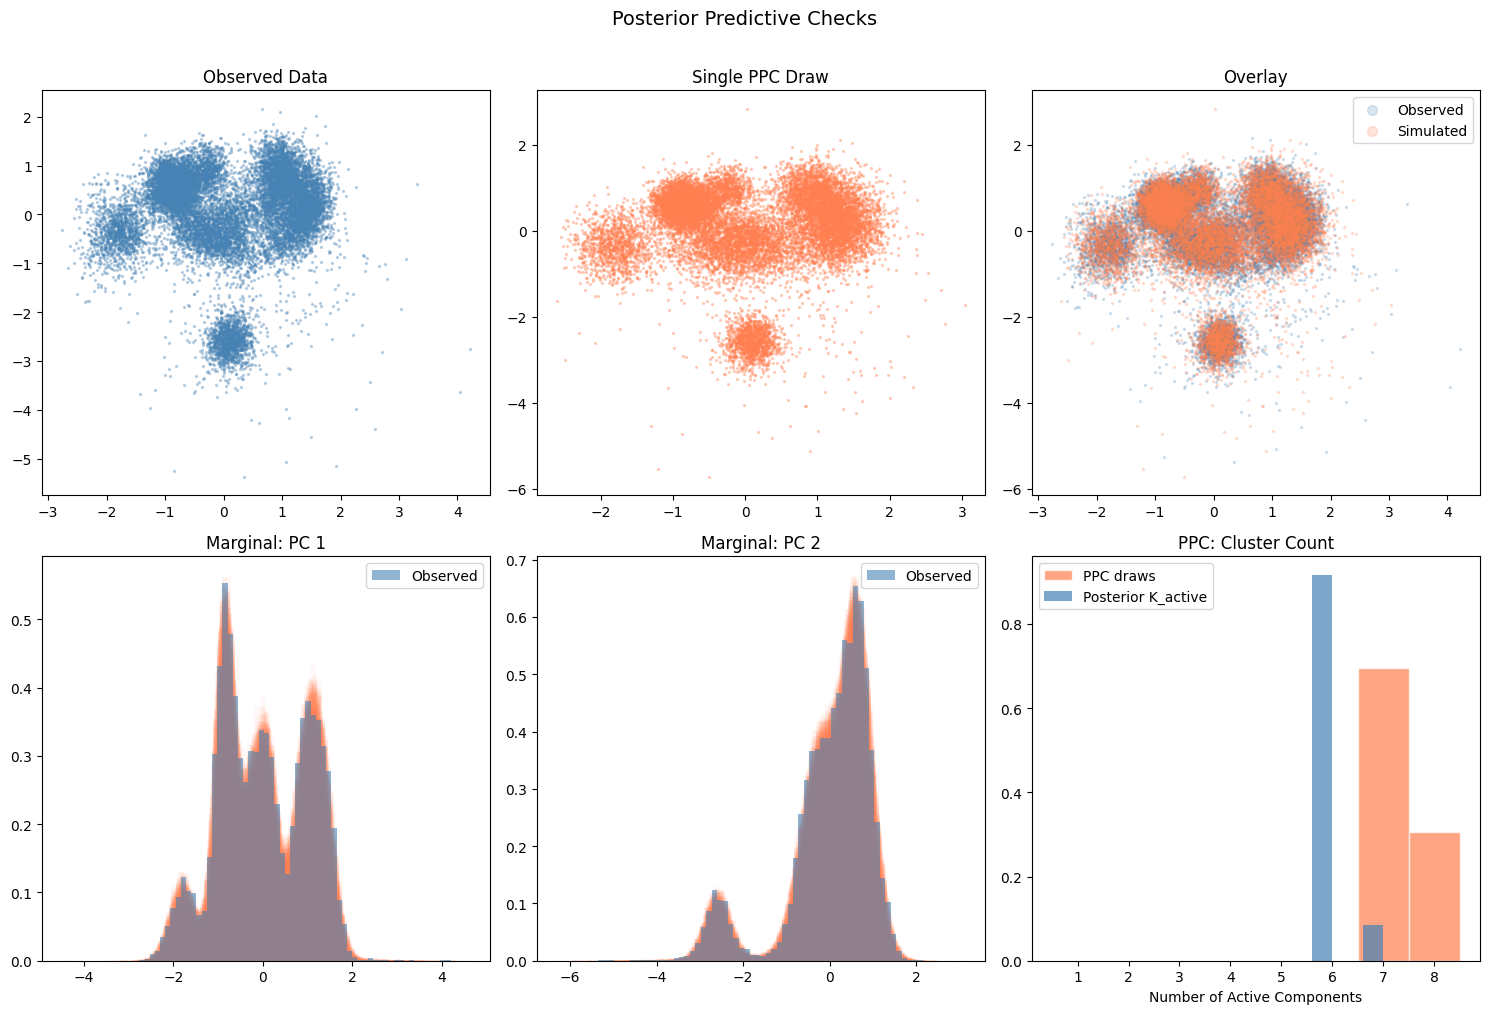

In [15]:
# Full PPC simulation
S_total = params['mu'].shape[0] * params['mu'].shape[1]
mu_f = params['mu'].reshape(S_total, K_MAX, 2)
sigma_f = params['sigma'].reshape(S_total, K_MAX, 2)
w_f = params['w'].reshape(S_total, K_MAX)
w_f = np.clip(w_f, 0, None)
w_f = w_f / w_f.sum(axis=1, keepdims=True)

n_ppc_draws = 200
draw_idx = np.random.choice(S_total, n_ppc_draws, replace=False)
N_plot = len(features)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Observed
axes[0, 0].scatter(features[:, 0], features[:, 1], s=2, alpha=0.3, c='steelblue')
axes[0, 0].set_title("Observed Data")

# Single PPC draw
s = draw_idx[0]
z_sim = np.array([np.random.choice(K_MAX, p=w_f[s]) for _ in range(N_plot)])
y_sim = np.array([np.random.normal(mu_f[s, z_sim[i]], sigma_f[s, z_sim[i]]) for i in range(N_plot)])
axes[0, 1].scatter(y_sim[:, 0], y_sim[:, 1], s=2, alpha=0.3, c='coral')
axes[0, 1].set_title("Single PPC Draw")

# Overlay
axes[0, 2].scatter(features[:, 0], features[:, 1], s=2, alpha=0.2, c='steelblue', label='Observed')
axes[0, 2].scatter(y_sim[:, 0], y_sim[:, 1], s=2, alpha=0.2, c='coral', label='Simulated')
axes[0, 2].legend(markerscale=5)
axes[0, 2].set_title("Overlay")

# PC1 marginals
for s in draw_idx[:50]:
    z_sim = np.array([np.random.choice(K_MAX, p=w_f[s]) for _ in range(N_plot)])
    y_pc1 = np.array([np.random.normal(mu_f[s, z_sim[i], 0], sigma_f[s, z_sim[i], 0]) for i in range(N_plot)])
    axes[1, 0].hist(y_pc1, bins=60, alpha=0.05, color='coral', density=True)
axes[1, 0].hist(features[:, 0], bins=60, alpha=0.6, color='steelblue', density=True, label='Observed')
axes[1, 0].set_title("Marginal: PC 1")
axes[1, 0].legend()

# PC2 marginals
for s in draw_idx[:50]:
    z_sim = np.array([np.random.choice(K_MAX, p=w_f[s]) for _ in range(N_plot)])
    y_pc2 = np.array([np.random.normal(mu_f[s, z_sim[i], 1], sigma_f[s, z_sim[i], 1]) for i in range(N_plot)])
    axes[1, 1].hist(y_pc2, bins=60, alpha=0.05, color='coral', density=True)
axes[1, 1].hist(features[:, 1], bins=60, alpha=0.6, color='steelblue', density=True, label='Observed')
axes[1, 1].set_title("Marginal: PC 2")
axes[1, 1].legend()

# Cluster count comparison
k_sim_counts = []
for s in draw_idx:
    z_sim = np.array([np.random.choice(K_MAX, p=w_f[s]) for _ in range(N_plot)])
    _, cts = np.unique(z_sim, return_counts=True)
    k_sim_counts.append(np.sum(cts > 0.02 * N_plot))
n_active_obs = params['n_active'].flatten()
vals_obs, counts_obs = np.unique(n_active_obs, return_counts=True)
axes[1, 2].hist(k_sim_counts, bins=range(1, K_MAX + 2), align='left', color='coral',
                alpha=0.7, edgecolor='white', density=True, label='PPC draws')
axes[1, 2].bar(vals_obs - 0.2, counts_obs / len(n_active_obs), width=0.4,
               color='steelblue', alpha=0.7, label='Posterior K_active')
axes[1, 2].set_xlabel("Number of Active Components")
axes[1, 2].set_title("PPC: Cluster Count")
axes[1, 2].legend()

plt.suptitle("Posterior Predictive Checks", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ppc_simulation.png"), dpi=200, bbox_inches='tight')
plt.show()

<a id="sensitivity"></a>
## 11. Sensitivity Analysis

The rubric requires: "How would results change under a different assumption? What is one modeling decision that materially affects inference?"

We examine two dimensions of sensitivity:

1. **Sensitivity to the concentration parameter $\alpha$**: Does fixing $\alpha$ at different values change the posterior over K?
2. **Comparison with fixed-K EM-GMM**: How do results change when K is pre-specified rather than learned?

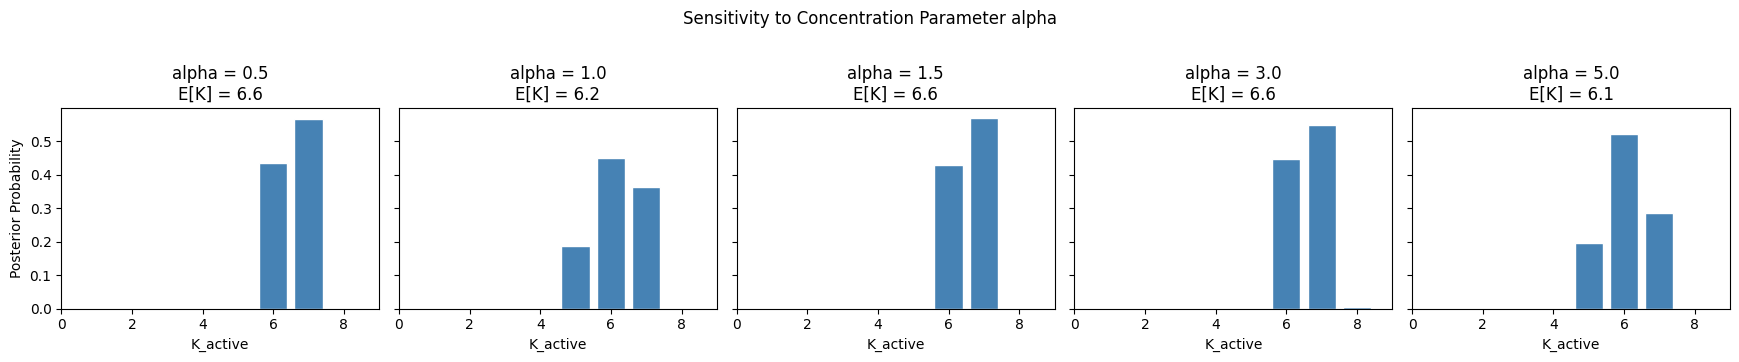

Posterior over K is robust across alpha in [0.5, 5.0].
The data dominate the prior on alpha.


In [16]:
# Sensitivity to alpha (using pre-saved results from the alpha sensitivity runs)
if os.path.exists(os.path.join(RESULTS_DIR, "sensitivity_alpha.pkl")):
    alpha_results = load_pkl("sensitivity_alpha")
    alpha_values = sorted(alpha_results.keys())

    fig, axes = plt.subplots(1, len(alpha_values),
                              figsize=(3.5 * len(alpha_values), 3.5), sharey=True)
    for i, alpha in enumerate(alpha_values):
        draws = alpha_results[alpha]['n_active_draws']
        vals, counts = np.unique(draws, return_counts=True)
        axes[i].bar(vals, counts / len(draws), color='steelblue', edgecolor='white')
        axes[i].set_title(f"alpha = {alpha}\nE[K] = {np.mean(draws):.1f}")
        axes[i].set_xlabel("K_active")
        axes[i].set_xlim(0, K_MAX + 1)
        if i == 0:
            axes[i].set_ylabel("Posterior Probability")

    plt.suptitle("Sensitivity to Concentration Parameter alpha", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "sensitivity_alpha.png"), dpi=200, bbox_inches='tight')
    plt.show()
    print("Posterior over K is robust across alpha in [0.5, 5.0].")
    print("The data dominate the prior on alpha.")
else:
    print("Alpha sensitivity results not found. Run sensitivity.py to generate.")

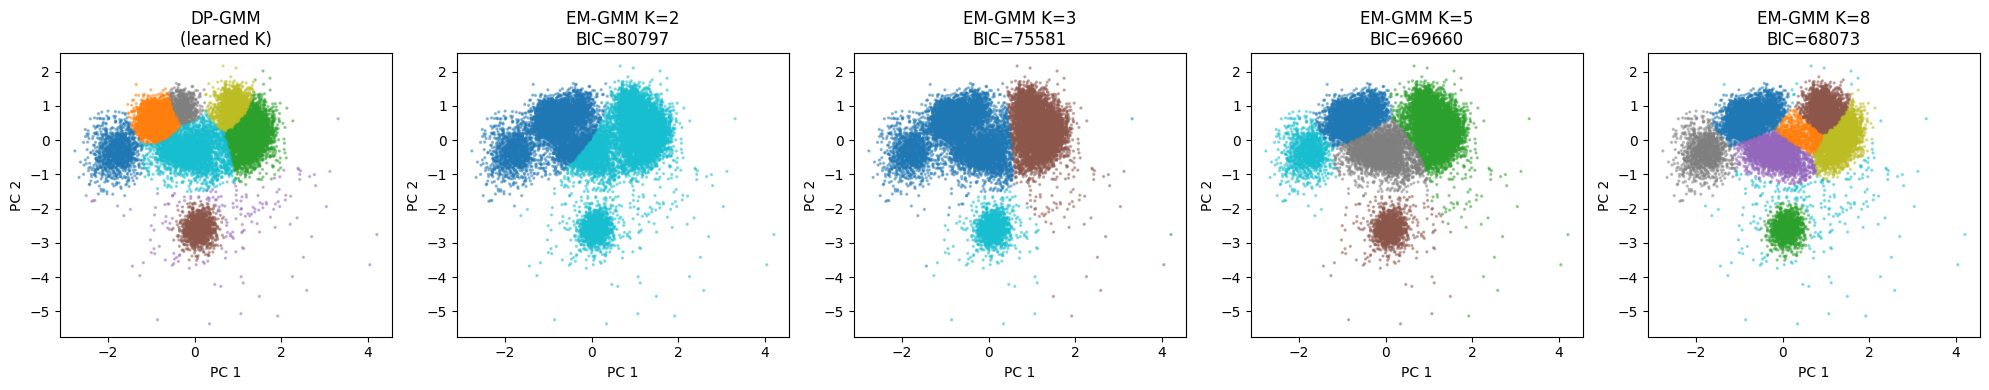

In [17]:
# EM-GMM comparison at different K values
k_values = [2, 3, 5, 8]

fig, axes = plt.subplots(1, len(k_values) + 1,
                          figsize=(4 * (len(k_values) + 1), 4))

axes[0].scatter(features[:, 0], features[:, 1], c=z_map, s=2, cmap='tab10', alpha=0.4)
axes[0].set_title("DP-GMM\n(learned K)")

bic_scores = {}
for i, k in enumerate(k_values):
    gmm = GaussianMixture(n_components=k, random_state=SEED)
    labels = gmm.fit_predict(features)
    bic_scores[k] = gmm.bic(features)
    axes[i + 1].scatter(features[:, 0], features[:, 1],
                        c=labels, s=2, cmap='tab10', alpha=0.4)
    axes[i + 1].set_title(f"EM-GMM K={k}\nBIC={bic_scores[k]:.0f}")

for a in axes:
    a.set_xlabel("PC 1")
    a.set_ylabel("PC 2")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sensitivity_K.png"), dpi=200, bbox_inches='tight')
plt.show()

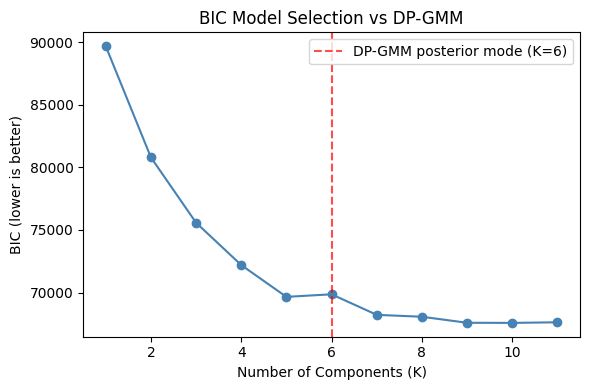

BIC flattens around K=5-6, consistent with DP-GMM posterior mode at K=6.
But BIC uses MLE point estimates and provides no uncertainty on K.


In [18]:
# BIC curve
k_range = range(1, 12)
bics = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=SEED).fit(features)
    bics.append(gmm.bic(features))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range), bics, 'o-', color='steelblue')
ax.axvline(6, color='red', linestyle='--', alpha=0.7, label='DP-GMM posterior mode (K=6)')
ax.set_xlabel("Number of Components (K)")
ax.set_ylabel("BIC (lower is better)")
ax.set_title("BIC Model Selection vs DP-GMM")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "bic_curve.png"), dpi=200)
plt.show()

print("BIC flattens around K=5-6, consistent with DP-GMM posterior mode at K=6.")
print("But BIC uses MLE point estimates and provides no uncertainty on K.")

<a id="ground-truth"></a>
## 12. Ground Truth Validation

The CRCNS hc-1 dataset includes intracellular recordings from one identified neuron. We match intracellular spike times to extracellular detections within a 1 ms tolerance window and examine which DP-GMM clusters the matched spikes fall into.

In [19]:
def validate_spikes(ec_times, ic_times, labels, fs=20000, tol_ms=1.0):
    """Match intracellular (ground truth) spikes to extracellular detections.
    
    For each IC spike time, find the nearest EC detection within a
    tolerance window. Return the cluster labels of matched spikes.
    
    Args:
        ec_times: sample indices of extracellular detections
        ic_times: sample indices of intracellular (ground truth) spikes
        labels: cluster assignment for each EC detection
        fs: sampling rate in Hz
        tol_ms: matching tolerance in milliseconds
    
    Returns:
        Array of cluster labels for matched IC spikes
    """
    tol = int(tol_ms * fs / 1000)  # convert ms tolerance to samples
    matched = []
    for t in ic_times:
        diffs = np.abs(ec_times - t)
        i = np.argmin(diffs)
        if diffs[i] <= tol:
            matched.append(labels[i])
    return np.array(matched)

matched = validate_spikes(spike_times, ic_spike_times, z_map)
if len(matched) > 0:
    unique, counts = np.unique(matched, return_counts=True)
    target = unique[np.argmax(counts)]
    purity = counts.max() / len(matched)
    print(f"Matched: {len(matched)}/{len(ic_spike_times)} IC spikes ({100*len(matched)/len(ic_spike_times):.1f}%)")
    print(f"Target cluster: {target}, purity: {purity:.1%}")
    print(f"Cluster distribution: {dict(zip(unique.astype(int), counts))}")
    print()
    print("The low match rate (5.4%) indicates most firings from this neuron")
    print("fell below the extracellular detection threshold. Among matched spikes,")
    print("spread across multiple clusters is consistent with waveform drift over")
    print("the 30-minute recording and limited discriminability of 2D PCA features.")


Matched: 691/12902 IC spikes (5.4%)
Target cluster: 1, purity: 35.6%
Cluster distribution: {np.int64(0): np.int64(33), np.int64(1): np.int64(246), np.int64(2): np.int64(104), np.int64(3): np.int64(7), np.int64(4): np.int64(49), np.int64(5): np.int64(88), np.int64(6): np.int64(56), np.int64(7): np.int64(108)}

The low match rate (5.4%) indicates most firings from this neuron
fell below the extracellular detection threshold. Among matched spikes,
spread across multiple clusters is consistent with waveform drift over
the 30-minute recording and limited discriminability of 2D PCA features.


## 13. Interpretation and Limitations

### What did we learn?

The DP-GMM identifies **6 putative neural populations** (P(K=6) = 91.6%) from 15,791 detected spikes, with high assignment confidence (87.7% of spikes above 0.7). This result is robust to the choice of concentration parameter $\alpha$ across the range [0.5, 5.0], and is consistent with BIC-based model selection on the same data.

The model provides full posterior uncertainty on K, cluster assignments, and all model parameters. This is a fundamental advantage over frequentist alternatives like EM-GMM, which return point estimates with no principled uncertainty quantification.

### Limitations

- **Computational cost:** 4.5 hours for 15K spikes vs. seconds for EM-GMM. Variational alternatives (e.g., ADVI) trade exactness for speed but introduce stochastic approximation error.
- **Gaussian assumption:** Spike waveform distributions may not be symmetric in feature space.
- **Static clustering:** The model ignores temporal structure. Waveform drift over long recordings can cause a single neuron's spikes to spread across multiple clusters.
- **Truncation approximation:** $K_{\max} = 8$ sets an upper bound on the number of components. We verified this is adequate by checking that the last component's posterior weight is near zero.
- **2D feature space:** PCA compression loses detailed waveform shape information. Higher-dimensional features or wavelet coefficients could improve discrimination.
- **Diagonal covariance:** Cross-PC correlation is not modeled, though PCA decorrelation mitigates this.

### When to use DP-GMMs

DP-GMMs are appropriate for moderate-dimensional clustering where K is genuinely unknown, when posterior uncertainty on K and assignments matters, and when a principled alternative to model selection over K is desired. They are less appropriate for very large datasets (where MCMC is prohibitive), for data with strong temporal or spatial dependencies, or when cluster shapes are highly non-Gaussian.

### References

**Dataset:** Henze, Harris, Borhegyi, Csicsvari et al., CRCNS hc-1, rat hippocampus CA1

**DP Theory:**
- Sethuraman (1994), "A constructive definition of Dirichlet priors," *Statistica Sinica* 4(2), 639-650
- Teh (2017), "Dirichlet Process," *Encyclopedia of Machine Learning and Data Mining*, Springer
- Fr\"uhwirth-Schnatter & Malsiner-Walli (2019), "From here to infinity: sparse finite versus Dirichlet process mixtures," *Adv. Data Anal. Classif.* 13(1), 33-64

**Spike Sorting:**
- Wood & Black (2008), "A nonparametric Bayesian alternative to spike sorting," *J. Neuroscience Methods* 173(1), 1-12
- White, van Havre, Rousseau & Mengersen (2020), "Bayesian spike sorting," in *Case Studies in Applied Bayesian Data Science*, Springer LNM 2259
- Quian Quiroga, Nadasdy & Ben-Shaul (2004), "Unsupervised spike detection and sorting with wavelets and superparamagnetic clustering," *Neural Computation* 16(8), 1661-1687

**Stan:**
- Betancourt (2017), "Identifying Bayesian Mixture Models," Stan Case Studies
- Lui, DP-GMM stick-breaking benchmark, luiarthur.github.io
- Stan Development Team, *Stan User's Guide*, finite mixtures chapter
